#Importing most of the packages

In [27]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

#creating transform

In [28]:
transform=transforms.Compose([
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1,contrast=0.1,hue=0.1),
    ToTensor(),
    transforms.Normalize(mean=(0.4914, 0.4822, 0.4465),std=(0.2470, 0.2435, 0.2616)),

])

## downloading train and test datasets

In [29]:
train_data=datasets.CIFAR10(root='data',
                            train=True,
                            download=True,
                            transform=transform)
test_data=datasets.CIFAR10(root='data',
                           train=False,
                           download=True,
                           transform=transform)

#Plotting images

In [30]:
mean=torch.tensor((0.4914, 0.4822, 0.4465))
std=torch.tensor([0.2470, 0.2435, 0.2616])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3682972..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9641825..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5766771..1.6211325].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4166123..1.2811464].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8783362..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7513218..1.8844646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.676823

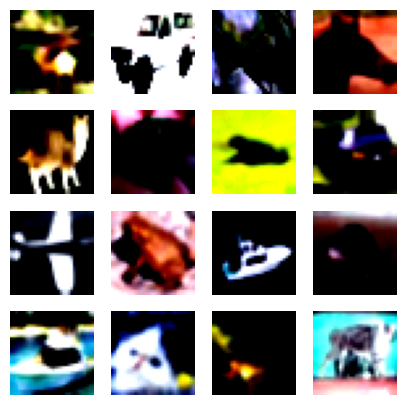

In [31]:
def image_plot(data,class_names):
  fig=plt.figure(figsize=(5,5))
  rows,cols=4,4
  for i in range(1,rows*cols+1):
    random_idx=torch.randint(0,len(data),size=[1]).item()
    img,label=data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze().permute(1,2,0),cmap="gray")
    plt.axis(False)
class_names=train_data.classes
image_plot(train_data,class_names)

#Dataloaders

In [32]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader=DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True)
test_dataloader=DataLoader(test_data,batch_size=BATCH_SIZE,shuffle=False)

images_batch,image_label_batch=next(iter(train_dataloader))
# images_batch,image_label_batch

#Creating a model

In [33]:

class CustomModel(nn.Module):
    def __init__(self, inpt, hidden, output):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(inpt, hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 32 → 16
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 16 → 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden*8*8, hidden),
            nn.ReLU(),
            nn.Linear(hidden, output)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.classifier(x)
        return x

#Device agnostic code

In [34]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

#Testing if model works?

In [35]:
model_0=CustomModel(3,30,len(class_names)).to(device)

#creating loss function and an optimizer

In [36]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.0001)

#Training and Testing Functions

In [37]:
pip install torchmetrics

Note: you may need to restart the kernel to use updated packages.


In [38]:
from torchmetrics import Accuracy
accuracy_fn=Accuracy(task="multiclass", num_classes=len(class_names)).to(device)
def train_step(model:nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:nn.Module,accuracy_fn,
               optimizer:torch.optim.Optimizer,
               device:torch.device):

  train_loss,train_acc=0,0
  model.train()
  accuracy_fn.reset()
  for batch,(X,y) in enumerate(dataloader):

    X=X.to(device)
    y=y.to(device)

    y_logits=model(X)
    loss=loss_fn(y_logits,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss+=loss.item()
    y_pred=torch.argmax(y_logits,dim=1)
    train_acc+=accuracy_fn(y_pred,y).item()

  train_loss/=len(dataloader)
  train_acc=train_acc/len(dataloader)

  return train_loss,train_acc
def test_step(model:nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:nn.Module,accuracy_fn,
               device:torch.device):

  test_loss,test_acc=0,0
  model.eval()
  accuracy_fn.reset()
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):

      X=X.to(device)
      y=y.to(device)

      y_logits=model(X)
      loss=loss_fn(y_logits,y)

      y_pred=torch.argmax(y_logits,dim=1)
      test_loss+=loss.item()
      test_acc+=accuracy_fn(y_pred,y).item()

    test_loss/=len(dataloader)
    test_acc/=len(dataloader)

  return test_loss,test_acc


#Its time to train and test

In [39]:
from tqdm.auto import tqdm
epochs=20
train_losses,train_accs,test_losses,test_accs=[],[],[],[]
train_loss,train_acc,test_loss,test_acc=0,0,0,0
for epoch in tqdm(range(epochs)):
  train_loss,train_acc=train_step(model=model_0,dataloader=train_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn,optimizer=optimizer,
                        device=device)
  test_loss,test_acc=train_step(model=model_0,dataloader=test_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn,optimizer=optimizer,
                        device=device)
  train_losses.append(train_loss)
  test_losses.append(test_loss)
  train_accs.append(train_acc)
  test_accs.append(test_acc)
  print(f"train loss:{train_loss} | train accuracy: {train_acc} | test loss: {test_loss} | test accuracy: {test_acc}")

  0%|          | 0/20 [00:00<?, ?it/s]

train loss:1.8270053035238196 | train accuracy: 0.34688899552143315 | test loss: 1.5716063983905049 | test accuracy: 0.4379992012779553
train loss:1.5016286782324504 | train accuracy: 0.46263195777351246 | test loss: 1.425420119739569 | test accuracy: 0.4904153354632588
train loss:1.4020326918542805 | train accuracy: 0.5009197056941779 | test loss: 1.3484435744178942 | test accuracy: 0.523861821086262
train loss:1.3357740163574292 | train accuracy: 0.5255318298144593 | test loss: 1.3002279058051185 | test accuracy: 0.5364416932907349
train loss:1.284496312826319 | train accuracy: 0.5451255598208573 | test loss: 1.249024888006643 | test accuracy: 0.5574081469648562
train loss:1.23982142677539 | train accuracy: 0.5627199296225208 | test loss: 1.2075052084252476 | test accuracy: 0.5710862619808307
train loss:1.197643758048633 | train accuracy: 0.5795345489443378 | test loss: 1.1635403204649781 | test accuracy: 0.5853634185303515
train loss:1.1614270525640658 | train accuracy: 0.5929702495

#Making evaluation of the model and do some random prediction

In [40]:
def make_pred(model:nn.Module,test_data,device=device):
  pred_probs=[]
  model.eval()
  with torch.inference_mode():
    for sample in test_data:
      sample=torch.unsqueeze(sample,dim=0).to(device)
      pred_logit=model(sample)
      pred_prob=torch.softmax(pred_logit,dim=1)
      pred_probs.append(pred_prob)
  return torch.stack(pred_probs)

In [41]:
import random
test_samples=[]
test_labels=[]
for sample,labels in random.sample(list(test_data),k=10):
  test_samples.append(sample)
  test_labels.append(labels)
test_samples[0].shape

torch.Size([3, 32, 32])

In [42]:
pred_probs=make_pred(model=model_0,test_data=test_samples)
pred_probs=pred_probs.squeeze(dim=1)
pred_probs.shape

torch.Size([10, 10])

In [43]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([0, 7, 5, 5, 6, 6, 3, 1, 0, 5], device='cuda:0')

#making random predictions

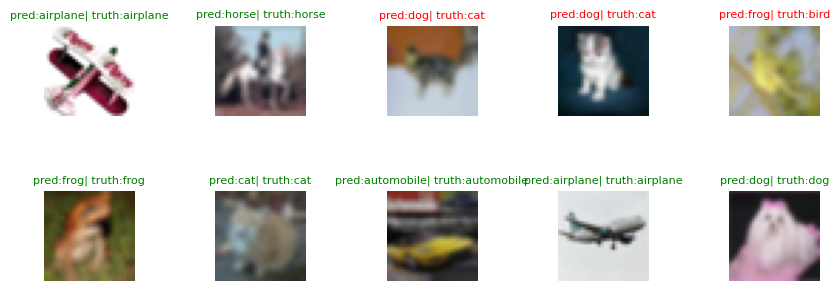

In [44]:
plt.figure(figsize=(10,10))
nrows,ncols=5,5
for i,sample in enumerate(test_samples):
  plt.subplots_adjust(wspace=0.9, hspace=0.5)
  sample_val=sample.squeeze().permute(1,2,0)
  sample_val=sample_val*std +mean
  sample_val=sample_val.clamp(0,1)
  plt.subplot(nrows,ncols,i+1)
  plt.imshow(sample_val,cmap='gray')
  pred_labels=class_names[pred_classes[i]]
  truth_labels=class_names[test_labels[i]]
  text_title=f"pred:{pred_labels}| truth:{truth_labels}"
  plt.axis(False)
  if pred_labels==truth_labels:
    plt.title(text_title,fontsize=8,color="green")
  else:
    plt.title(text_title,fontsize=8,color="red")

In [45]:
# Downloading mlxtend

In [47]:
y_preds=[]

model_0.eval()
with torch.inference_mode():
    for batch,(x,y) in tqdm(enumerate(test_dataloader),desc="making total predictions"):
        x,y=x.to(device),y.to(device)
        y_logits=model_0(x)
        y_pred=torch.softmax(y_logits,dim=1).argmax(dim=1)
        y_preds.append(y_pred.cpu())


making total predictions: 0it [00:00, ?it/s]

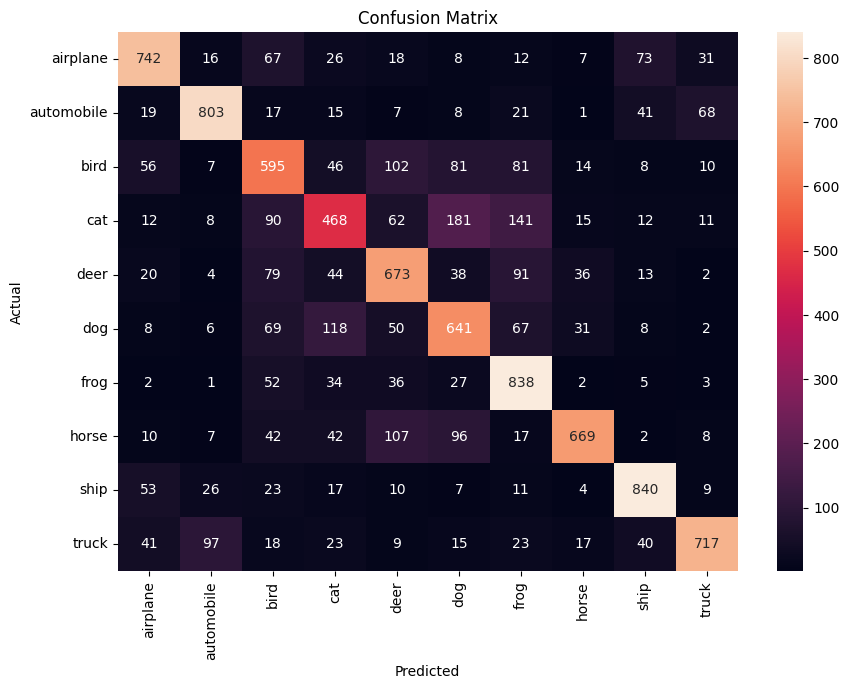

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt
from torchmetrics import ConfusionMatrix
import torch



y_true = torch.tensor(test_data.targets)
y_preds=torch.cat(y_preds)

conf = ConfusionMatrix(task='multiclass', num_classes=len(class_names))
conf_tensor = conf(preds=y_preds, target=y_true)

cm = conf_tensor.cpu().numpy()

# plot
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#plotting the loss curves

In [52]:
model_0_results={}
model_0_results['test_loss']=test_losses
model_0_results['test_accuracy']=test_accs
model_0_results['train_accuracy']=train_accs
model_0_results['train_loss']=train_losses

In [53]:
model_0_results.keys()

dict_keys(['test_loss', 'test_accuracy', 'train_accuracy', 'train_loss'])

20
20


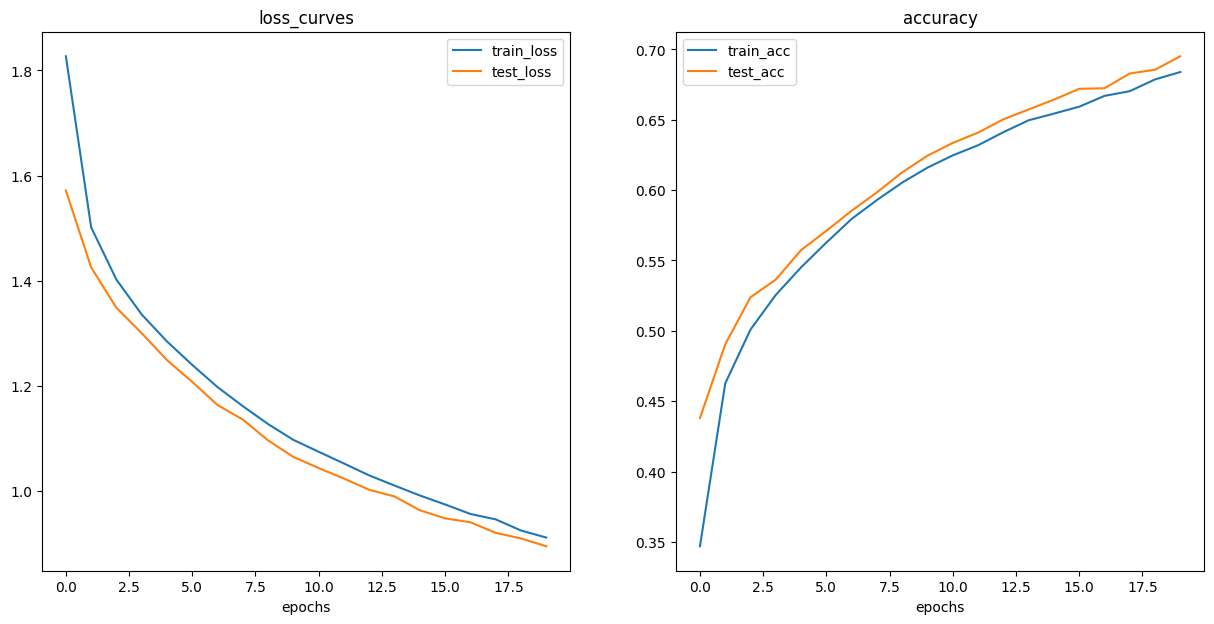

In [54]:
def plot_loss_curves(results:dict):
    train_loss=results['train_loss']
    test_loss=results['test_loss']
    train_accuracy=results['train_accuracy']
    test_accuracy=results['test_accuracy']
    epochs=range(len(results['train_loss']))
    plt.figure(figsize=(15,7))
    plt.subplot(1,2,1)
    plt.plot(epochs,train_loss,label='train_loss')
    plt.plot(epochs,test_loss,label='test_loss')
    print(len(train_loss))
    print(len(train_accuracy))
    plt.title('loss_curves')
    plt.xlabel('epochs')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs,train_accuracy,label='train_acc')
    plt.plot(epochs,test_accuracy,label='test_acc')
    plt.title('accuracy')
    plt.xlabel('epochs')
    plt.legend()
    plt.show()
plot_loss_curves(model_0_results)